# 10 - Calibration drift: non-stationarity, or the first true win for adaptivity

Notebooks 08 and 09 established that in a **stationary** regime, a well-built
threshold test ties or beats ML. This notebook introduces what every instrument
engineer knows: **the gain of a measurement chain drifts** - orbital thermal cycling
(a satellite's day/night), ageing photodiodes, readout-laser power fluctuation. A
threshold calibrated on the ground at t0 lies in flight at t0 + 6 months.

### The model

$$g(t) = A\sin\!\left(\frac{2\pi t}{T}\right), \qquad
\hat{c}_i(t) = \big(1 + g(t)\big)\,c_i + \varepsilon_i, \qquad
\varepsilon_i \sim \mathcal{N}\!\big(0, \sigma^2\big)$$

A slowly oscillating gain (T = 2000 acquisitions, A = 8%). Consequence: the apparent
norm of a perfectly valid state read at the drift peak is $(1.08)^2 \approx 1.17$ -
far outside the +/-0.05 validity band. **The fixed threshold is structurally doomed.**

### The five contenders

1. **Fixed threshold** (the champion of notebooks 08-09);
2. **Online recalibration** - the domain answer: rolling median of the estimated norm
   as a local gain estimator, then a threshold on the detrended norm;
3. **Random Forest** with the 12 features + acquisition time;
4. **Gradient boosting on (norm, time) alone** - ML with the right representation;
5. **Physics + ML hybrid** - RF also receiving the recalibrated statistic.

As in the previous notebooks: experiments executed before interpretations.

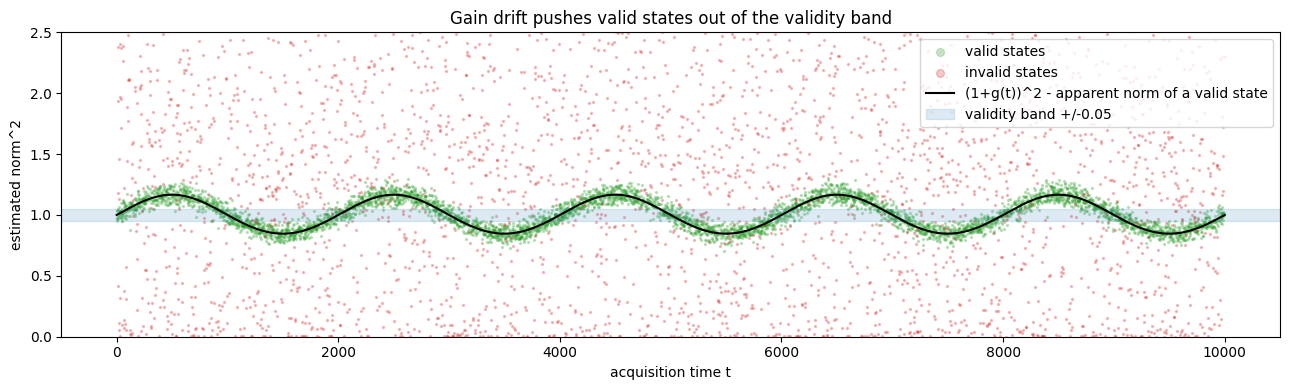

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from qsv.data_generation import create_dataset
from qsv.features import (
    add_calibration_drift,
    add_measurement_noise,
    compute_features,
    sigma_from_shots,
)

RANDOM_STATE, DIM, N = 42, 4, 500
A_DRIFT, T_DRIFT = 0.08, 2000
sigma = sigma_from_shots(N)

df = create_dataset(5000, 5000, dim=DIM, seed=RANDOM_STATE)
d = add_calibration_drift(df, n_shots=N, drift_amplitude=A_DRIFT,
                          drift_period=T_DRIFT, seed=RANDOM_STATE)
y = d["is_valid"]

fig, ax = plt.subplots(figsize=(13, 4))
t = d["acquisition_time"]
for label, color, name in [(1, "tab:green", "valid"), (0, "tab:red", "invalid")]:
    m = d["is_valid"] == label
    ax.scatter(t[m], d.loc[m, "norm_squared"], s=2, alpha=0.25, color=color, label=f"{name} states")
gain2 = (1 + A_DRIFT * np.sin(2 * np.pi * t / T_DRIFT)) ** 2
ax.plot(t, gain2, "k-", lw=1.5, label="(1+g(t))^2 - apparent norm of a valid state")
ax.axhspan(0.95, 1.05, color="tab:blue", alpha=0.15, label="validity band +/-0.05")
ax.set_ylim(0, 2.5); ax.set_xlabel("acquisition time t"); ax.set_ylabel("estimated norm^2")
ax.set_title("Gain drift pushes valid states out of the validity band")
ax.legend(loc="upper right", markerscale=4)
plt.tight_layout(); plt.show()

The figure says it all: the green sheet (valid states) follows the gain sinusoid and
**periodically leaves the validity band**. Any fixed threshold will accept invalids
near the curve and reject valids at the cycle peak. Let us measure.

fixed threshold             : 0.9368
online recalibration        : 0.9636
RF (12 features + time)     : 0.9388
GBM (norm + time only)      : 0.9620
physics + ML hybrid         : 0.9668
(no-drift reference, fixed threshold): 0.9724


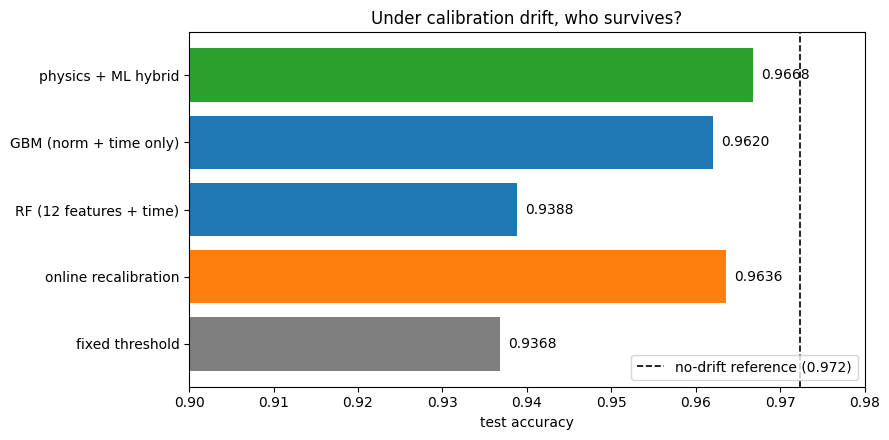

In [2]:
idx_tr, idx_te = train_test_split(np.arange(len(d)), test_size=0.25,
                                  stratify=y, random_state=RANDOM_STATE)

def stump_acc(stat, depth=2):
    s = stat.to_frame("s")
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(s.iloc[idx_tr], y.iloc[idx_tr])
    return accuracy_score(y.iloc[idx_te], m.predict(s.iloc[idx_te]))

def model_acc(model, X):
    model.fit(X.iloc[idx_tr], y.iloc[idx_tr])
    return accuracy_score(y.iloc[idx_te], model.predict(X.iloc[idx_te]))

results = {}

# 1. Fixed threshold (bias-corrected, as in notebook 08)
stat_fixed = np.abs(d["norm_squared"] - 1.0 - 2 * DIM * sigma**2)
results["fixed threshold"] = stump_acc(stat_fixed)

# 2. Online recalibration: rolling median as a local gain^2 estimator
med = d["norm_squared"].rolling(201, center=True, min_periods=50).median()
stat_recal = np.abs(d["norm_squared"] / med - 1.0)
results["online recalibration"] = stump_acc(stat_recal)

# 3. RF: 12 features + time
feats = pd.concat([d[[c for c in d.columns if c.startswith("c")]],
                   compute_features(d, kind="all")], axis=1)
feats_t = feats.copy(); feats_t["acquisition_time"] = d["acquisition_time"]
results["RF (12 features + time)"] = model_acc(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), feats_t)

# 4. GBM on (norm, time) ALONE - the right representation
results["GBM (norm + time only)"] = model_acc(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    d[["norm_squared", "acquisition_time"]])

# 5. Hybrid: RF with the recalibrated statistic as a feature
feats_h = feats_t.copy(); feats_h["norm_recalibrated"] = stat_recal
results["physics + ML hybrid"] = model_acc(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), feats_h)

# Reference: same noise WITHOUT drift
d0 = add_measurement_noise(df, n_shots=N, seed=RANDOM_STATE)
s0 = np.abs(d0["norm_squared"] - 1.0 - 2 * DIM * sigma**2).to_frame("s")
m0 = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
m0.fit(s0.iloc[idx_tr], y.iloc[idx_tr])
ref = accuracy_score(y.iloc[idx_te], m0.predict(s0.iloc[idx_te]))

for k, v in results.items():
    print(f"{k:28s}: {v:.4f}")
print(f"{'(no-drift reference, fixed threshold)':28s}: {ref:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
names = list(results)
vals = [results[k] for k in names]
colors = ["tab:gray", "tab:orange", "tab:blue", "tab:blue", "tab:green"]
ax.barh(names, vals, color=colors)
ax.axvline(ref, color="k", ls="--", lw=1.2, label=f"no-drift reference ({ref:.3f})")
ax.set_xlim(0.90, 0.98); ax.set_xlabel("test accuracy")
ax.set_title("Under calibration drift, who survives?")
for i, v in enumerate(vals):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=10)
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## Verdict - four lessons, from expected to subtle

1. **Non-stationarity breaks the fixed threshold** (0.972 -> 0.937): first defeat of
   the notebooks 08-09 champion. Expected - an instrument whose gain drifts by +/-8%
   cannot be qualified by a constant.

2. **The domain answer holds its rank**: online recalibration (rolling median, zero
   learning, one window) recovers most of the loss (0.964). That is what embedded
   systems actually do: periodic recalibration, not learned models. Subtlety: the
   median works here because ~50% of each window's states are valid and form a tight
   cluster at (1+g)^2 - the local gain estimator is barely polluted by the scattered
   invalids.

3. **ML fails or succeeds by its representation - not by its power.** The RF drowned
   in 12 features + time stalls at 0.939, barely above the collapsed fixed threshold:
   the fine norm-time interaction dilutes among irrelevant dimensions. The same
   problem given to a gradient boosting on **(norm, time) alone** reaches 0.962: the
   model learns the calibration map g(t) - the learned version of the black curve in
   the first figure. Third appearance of the same lesson since notebook 08:
   *representation beats algorithm*.

4. **The best system is hybrid** (0.967): the recalibrated statistic (physics) given
   as a feature to the forest (ML). Domain knowledge encodes in one line what the
   model would need thousands of examples to approximate; ML adds the handling of the
   residual cases. That is the architecture of real embedded qualification systems: a
   calibrated physics core, a learned layer for the residuals.

### Aerospace link

This notebook is the scale model of the **orbital thermal cycle**: a low-Earth-orbit
satellite crosses shadow and sunlight ~15 times a day, and every embedded measurement
chain sees its gain oscillate accordingly. The strategies compared here are exactly
those of real engineering: ground-qualified threshold (contender 1), periodic in-flight
recalibration (contender 2), calibration map learned on the ground from telemetry
(contender 4), hybrid architecture (contender 5). The hierarchy measured here -
domain ~ well-represented ML < hybrid - is the one found in operational FDIR systems.

### Milestone 4 status

With notebooks 09 and 10, milestone 4 answered its question: **ML earns its place when
the problem is non-stationary or requires multiclass diagnosis - and it earns it best
married to the physical structure, not opposed to it.** Remaining: known-target QA
(notebook 11) and scaling/sizing (notebook 12).